# Housing-Classification using KNN and Decision Tree MODEL 

## IMPORT LIBRARIES

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # library for plotting
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


import warnings # to hide unnecesary warning

## READING THE DATASET

In [43]:
df = pd.read_csv("ParisHousingClass.csv")

## DATA OVERVIEW

In [44]:
df.head()

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price,category
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5,Basic
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5,Luxury
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1,Basic
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2,Basic
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0,Luxury


## CHECKING THE MISSING DATA

In [45]:
#checking null num
df.isnull().sum()

squareMeters         0
numberOfRooms        0
hasYard              0
hasPool              0
floors               0
cityCode             0
cityPartRange        0
numPrevOwners        0
made                 0
isNewBuilt           0
hasStormProtector    0
basement             0
attic                0
garage               0
hasStorageRoom       0
hasGuestRoom         0
price                0
category             0
dtype: int64

## Check type of data

In [46]:
#information data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  int64  
 10  hasStormProtector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              1000

## Check the length of data each category

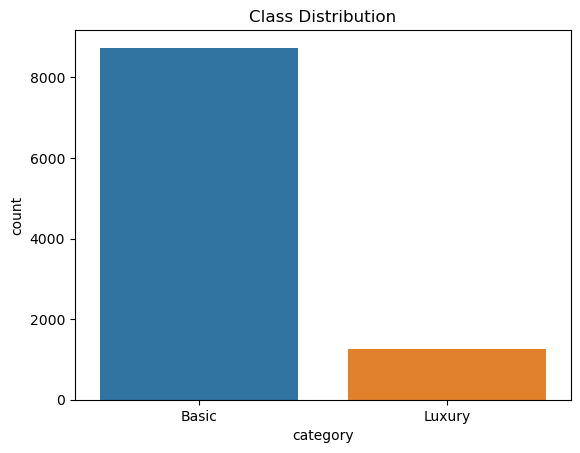

category
Basic     8735
Luxury    1265
Name: count, dtype: int64


In [47]:
sns.countplot(x="category", data=df)

plt.title("Class Distribution")
plt.show()

print(df["category"].value_counts())

## SPILITING DATA

In [48]:
X = df.drop('category', axis = 1) # Features: all columns except 'category'
y = df['category']                # Target: 'category' column

X_train, X_test, y_train, y_test = train_test_split( # Split the data first (this defines 'train' and 'test')
    X, 
    y, 
    test_size=0.3, 
    random_state=101,
    stratify=y   # Keep class distribution the same
)

In [49]:
y

0        Basic
1       Luxury
2        Basic
3        Basic
4       Luxury
         ...  
9995     Basic
9996     Basic
9997     Basic
9998     Basic
9999     Basic
Name: category, Length: 10000, dtype: object

In [50]:
print(y_train.value_counts())

category
Basic     6115
Luxury     885
Name: count, dtype: int64


# SCALLING DATA

In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELING DATA

## KKN MODEL

In [52]:
# Initialize the KNN model with k=
knn = KNeighborsClassifier(n_neighbors=3, weights='distance')

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on the test data
y_pred = knn.predict(X_test_scaled)

# Evaluate and print accuracy
score = metrics.accuracy_score(y_test, y_pred)
print(f"KNN Accuracy with k=3: {score:.3f}")

KNN Accuracy with k=3: 0.990


In [53]:
# empty variable for storing the K metrix
scores=[]

lrange=list(range(1,20))

# loop the KNN process
for k in lrange:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', algorithm='auto')
    knn.fit(X_train_scaled,y_train)
    
    # see KNN prediction by inputting the test data
    y_pred = knn.predict(X_test_scaled)
    
    # append the performance metric (accuracy)
    scores.append(metrics.accuracy_score(y_test,y_pred))

optimal_k = lrange[scores.index(max(scores))]


## Line Figure KNN

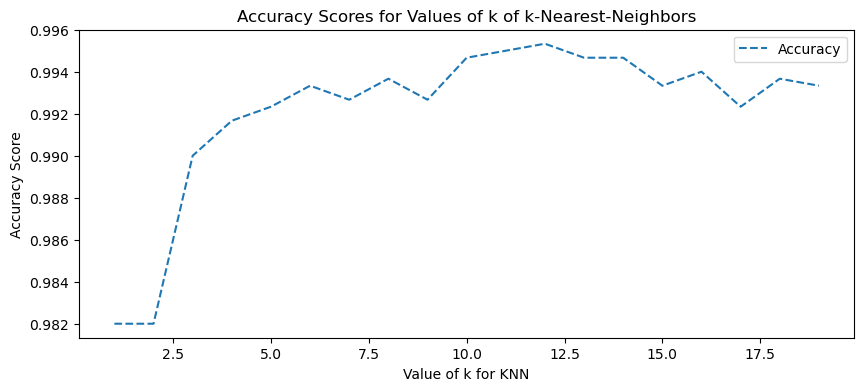

In [54]:
plt.figure(2,figsize=(10,4))

# plot the results
plt.plot(lrange, scores,ls='dashed', label= 'Accuracy')
plt.legend()
plt.xlabel('Value of k for KNN')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Scores for Values of k of k-Nearest-Neighbors')
plt.show()

## Final KNN 

In [55]:
# Final KNN Model
knn = KNeighborsClassifier(
    n_neighbors=optimal_k,
    weights='distance',
    algorithm='auto'
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = metrics.accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.9953333333333333


### Confusion Matrix

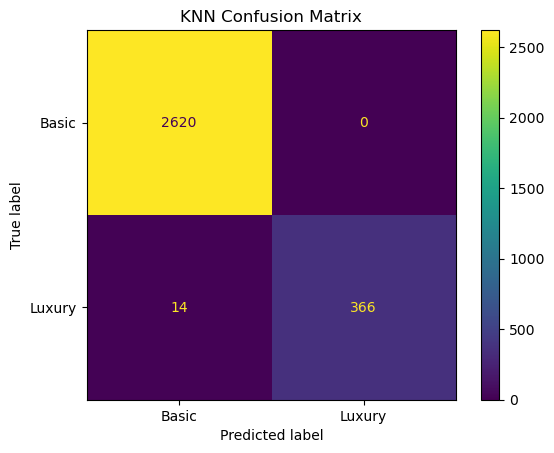

[[2620    0]
 [  14  366]]


In [56]:
ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("KNN Confusion Matrix")
plt.show()

print(confusion_matrix (y_test , y_pred))

In [57]:
#CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Basic       0.99      1.00      1.00      2620
      Luxury       1.00      0.96      0.98       380

    accuracy                           1.00      3000
   macro avg       1.00      0.98      0.99      3000
weighted avg       1.00      1.00      1.00      3000



# DECISION TREE MODELING

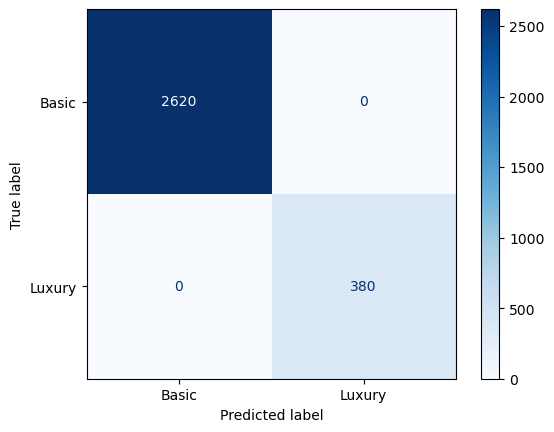

In [62]:
dtree = DecisionTreeClassifier(random_state=42)

dtree.fit(X_train_scaled, y_train)

dt_pred = dtree.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Blues"
)

plt.show()

## Ploting Desicion Tree

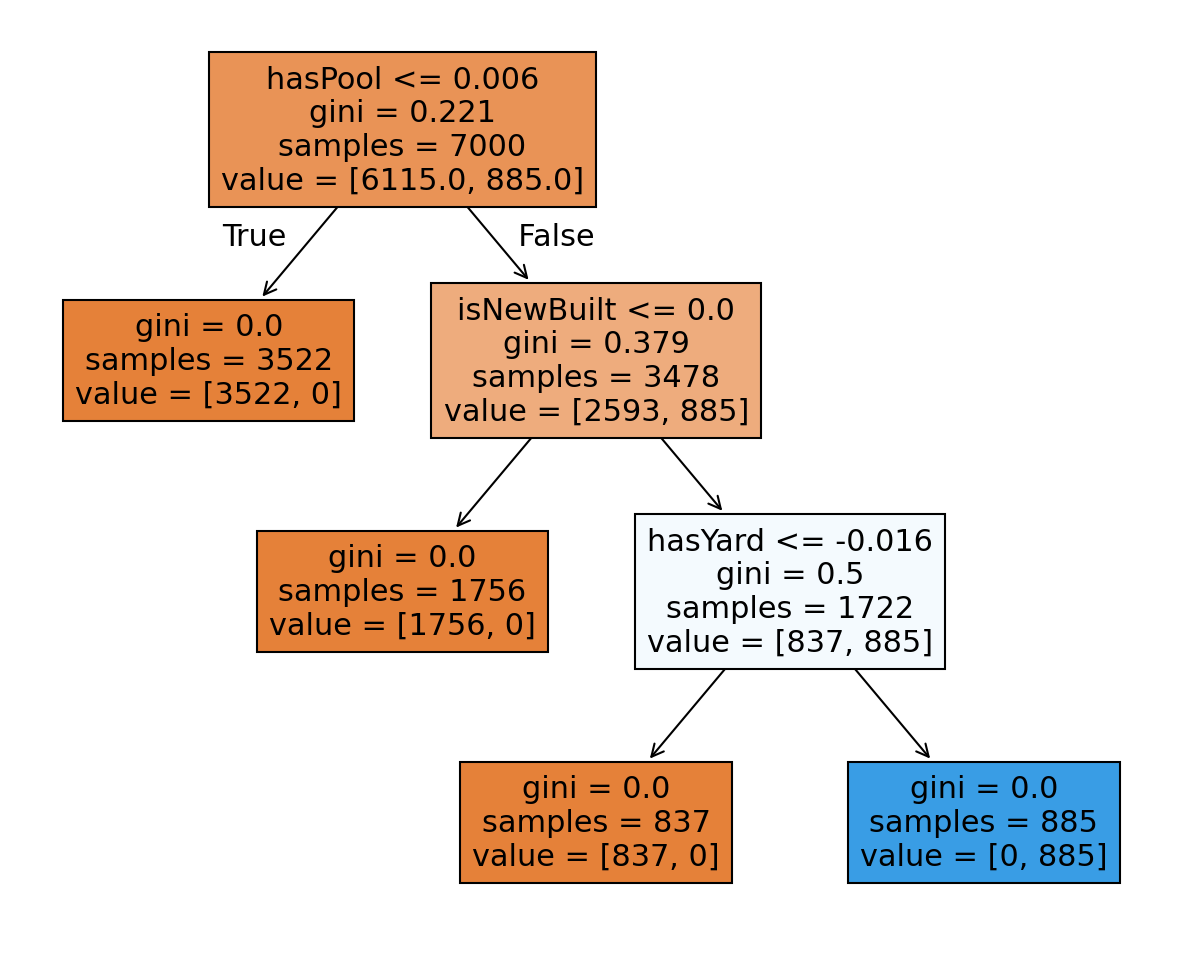

In [59]:
plt.figure(figsize=(10, 8), dpi=150)
plot_tree(dtree, filled=True, feature_names=X.columns);

## Classification Report DS Tree

In [61]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

       Basic       1.00      1.00      1.00      2620
      Luxury       1.00      1.00      1.00       380

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

